<a href="https://colab.research.google.com/github/kasyraf109-stack/ecommerce-customer-analysis/blob/main/online_retail_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Online Retail Sales Analysis**

**Project Objective**

This project analyzes an online retail dataset to identify:
- Top-selling countries
- Revenue trends
- Customer purchasing behavior
- Best-performing products

**Import, Load & Inspect Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/Online Retail.xlsx'

df = pd.read_excel(file_path)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
# Show all unique countries
countries = df['Country'].unique()

print(countries)

['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany' 'Norway'
 'EIRE' 'Switzerland' 'Spain' 'Poland' 'Portugal' 'Italy' 'Belgium'
 'Lithuania' 'Japan' 'Iceland' 'Channel Islands' 'Denmark' 'Cyprus'
 'Sweden' 'Austria' 'Israel' 'Finland' 'Bahrain' 'Greece' 'Hong Kong'
 'Singapore' 'Lebanon' 'United Arab Emirates' 'Saudi Arabia'
 'Czech Republic' 'Canada' 'Unspecified' 'Brazil' 'USA'
 'European Community' 'Malta' 'RSA']


**Top 10 Countries by Revenue (Excluding UK)**

In [ ]:
# Remove cancelled orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Reset index
df = df.reset_index(drop=True)

# Create revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Calculate total revenue
total_revenue = df['Revenue'].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 10,644,560.42


In [ ]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

country_sales_df = country_sales.reset_index()

country_sales_df.head(10).style.format({'Revenue': '{:,.2f}'})

,Country,Revenue
0,United Kingdom,"9,003,097.96"
1,Netherlands,"285,446.34"
2,EIRE,"283,453.96"
3,Germany,"228,867.14"
4,France,"209,715.11"
5,Australia,"138,521.31"
6,Spain,"61,577.11"
7,Switzerland,"57,089.90"
8,Belgium,"41,196.34"
9,Sweden,"38,378.33"


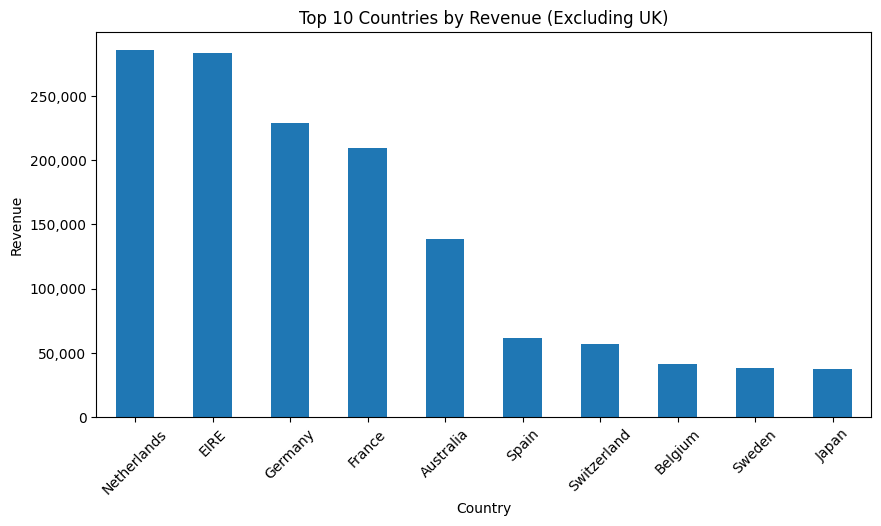

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Exclude United Kingdom (outlier value)
top_countries = country_sales[country_sales.index != 'United Kingdom'].head(10)

# Plot chart
ax = top_countries.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Countries by Revenue (Excluding UK)')
plt.xlabel('Country')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

# Add comma formatting
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

**Monthly Revenue Trend**

In [ ]:
# Check for incomplete December 2011 data
df[df['YearMonth'] == '2011-12']['InvoiceDate'].agg(['min', 'max'])

,InvoiceDate
min,2011-12-01 08:33:00
max,2011-12-09 12:50:00


In [ ]:
# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Remove incomplete December 2011 data
df_complete = df[df['InvoiceDate'] < '2011-12-01'].copy()

# Create Year-Month column
df_complete['YearMonth'] = df_complete['InvoiceDate'].dt.to_period('M')

# Aggregate monthly sales
monthly_sales = df_complete.groupby('YearMonth')['Revenue'].sum()

# Convert index to string for plotting
monthly_sales.index = monthly_sales.index.astype(str)

# Display result
print(monthly_sales)

YearMonth
2010-12     823746.140
2011-01     691364.560
2011-02     523631.890
2011-03     717639.360
2011-04     537808.621
2011-05     770536.020
2011-06     761739.900
2011-07     719221.191
2011-08     737014.260
2011-09    1058590.172
2011-10    1154979.300
2011-11    1509496.330
Name: Revenue, dtype: float64


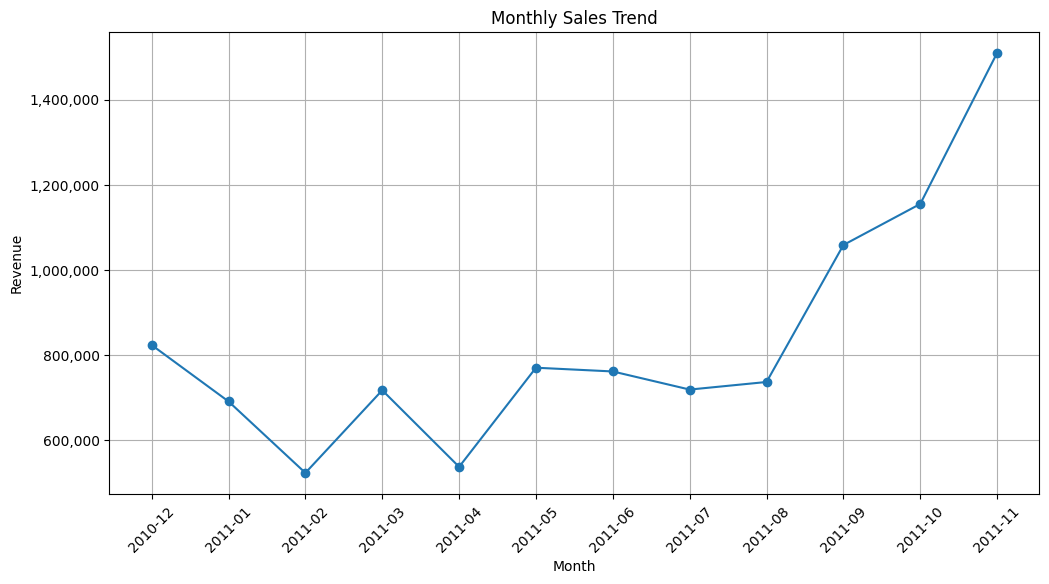

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Create formatter function
formatter = FuncFormatter(lambda x, p: format(int(x), ','))

# Plot
plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

# Rotate x-axis labels
plt.xticks(rotation=45)

# Apply comma formatting to y-axis
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(True)

plt.show()

**Top 10 Products by Revenue**

In [ ]:
unique_products = df['StockCode'].nunique()

print(f"Number of unique products: {unique_products}")

Number of unique products: 4070


In [ ]:
filtered_df = df[
    ~df['Description'].isin(['DOTCOM POSTAGE', 'POSTAGE', 'Manual'])
]

top_products_df = (
    filtered_df.groupby(['StockCode', 'Description'])
      .agg(
          Total_Quantity_Sold=('Quantity', 'sum'),
          Total_Revenue=('Revenue', 'sum')
      )
      .reset_index()
      .sort_values(by='Total_Revenue', ascending=False)
      .head(20)
)

# Format revenue
top_products_df['Total_Revenue'] = (
    top_products_df['Total_Revenue']
    .map(lambda x: f"${x:,.2f}")
)

top_products_df

,StockCode,Description,Total_Quantity_Sold,Total_Revenue
1461,22423,REGENCY CAKESTAND 3 TIER,13890,"$174,484.74"
2939,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"$168,469.60"
4359,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37603,"$104,340.29"
3040,47566,PARTY BUNTING,18299,"$99,504.33"
4346,85099B,JUMBO BAG RED RETROSPOT,48478,"$94,340.05"
2365,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"$81,700.92"
2251,23084,RABBIT NIGHT LIGHT,30788,"$66,964.99"
1114,22086,PAPER CHAIN KIT 50'S CHRISTMAS,19355,"$64,952.29"
3284,84879,ASSORTED COLOUR BIRD ORNAMENT,36461,"$59,094.93"
3122,79321,CHILLI LIGHTS,10309,"$54,117.76"


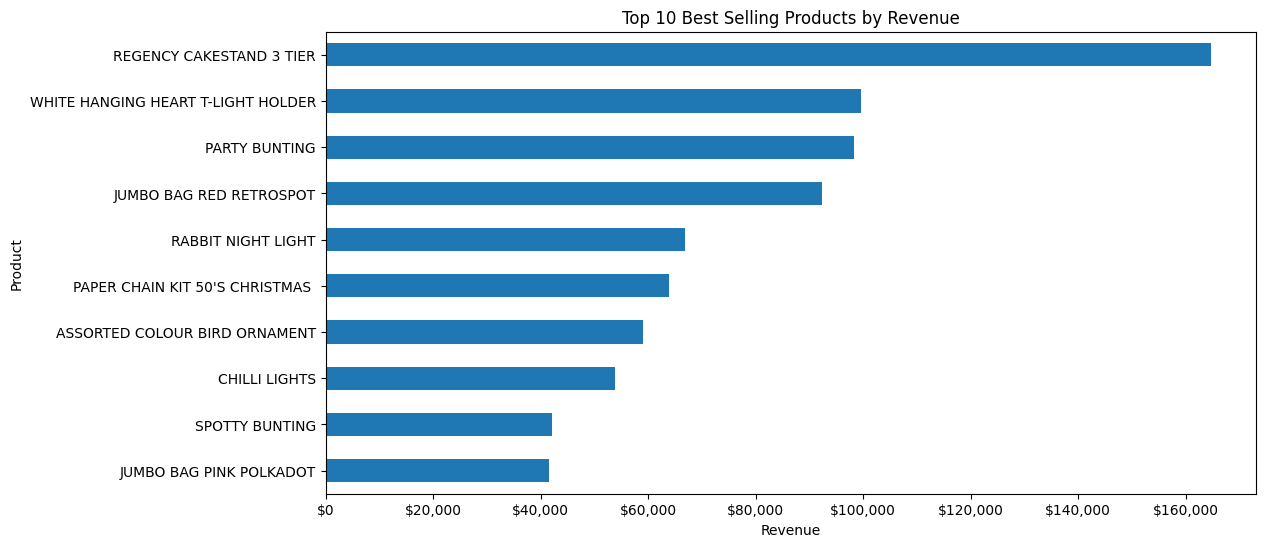

In [ ]:
import matplotlib.pyplot as plt

top10 = (
    filtered_df.groupby('Description')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top10.sort_values().plot(kind='barh')

plt.xlabel('Revenue')
plt.ylabel('Product')
plt.title('Top 10 Best Selling Products by Revenue')

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.show()

**Key Insights**

The United Kingdom dominates total revenue generation with more than 9 million in sales, contributing significantly more revenue than any other country in the dataset.

After excluding the UK to reduce skewness, the highest revenue-generating international markets are:

- Netherlands
- Ireland (listed as EIRE in the dataset)
- Germany
- France

Revenue drops noticeably after the top five countries, suggesting that sales are concentrated in a relatively small number of key international markets.

Monthly revenue shows a generally upward trend throughout 2011, indicating overall business growth over time.

A significant growth trend can be observed from September 2011 to November 2011:

- September: ~1.06M
- October: ~1.15M
- November: ~1.51M




**Conclusion**

This project analyzed an online retail transaction dataset to identify revenue patterns across countries, months, and products. After cleaning the dataset by removing cancelled orders and records with missing customer IDs, the analysis focused on actual completed customer purchases.

The findings show that the business is highly dependent on the UK market, but several international markets also contribute meaningful revenue. The monthly trend suggests that sales increased toward the end of 2011, although December 2011 was excluded because it only contained partial data. The product analysis also shows that certain products act as major revenue drivers.

Overall, this project demonstrates how sales transaction data can be used to generate practical business insights. The results can help support decisions related to inventory planning, international market focus, and product-level marketing strategy.